# Physics-Constrained UQ Tutorial

Physics-constrained UQ ensures that prediction intervals respect known physical laws. Standard UQ methods may produce intervals that violate:
- **Positivity** (e.g., concentrations can't be negative)
- **Conservation** (e.g., mass must integrate to a constant)
- **Monotonicity** (e.g., cumulative distributions must be non-decreasing)
- **Bounds** (e.g., probabilities ∈ [0,1])

These constraints narrow the predictive distribution to the physically feasible region, giving sharper and more meaningful uncertainty estimates.

# Physics-Constrained Uncertainty

Apply physical constraints to UQ predictions.

### Applying Constraint

Positivity constraints clip or reshape the predictive distribution so that no samples fall below zero — essential for physical quantities like mass, energy, or concentration that are inherently non-negative.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from deepuq.constraints import PositivityConstraint, ConservationConstraint, MonotonicityConstraint, apply_constraints
from deepuq.types import UQResult

## Positivity Constraint

Before: 25 negative values
Min value: -1.300

After: 0 negative values
Min value: 0.000


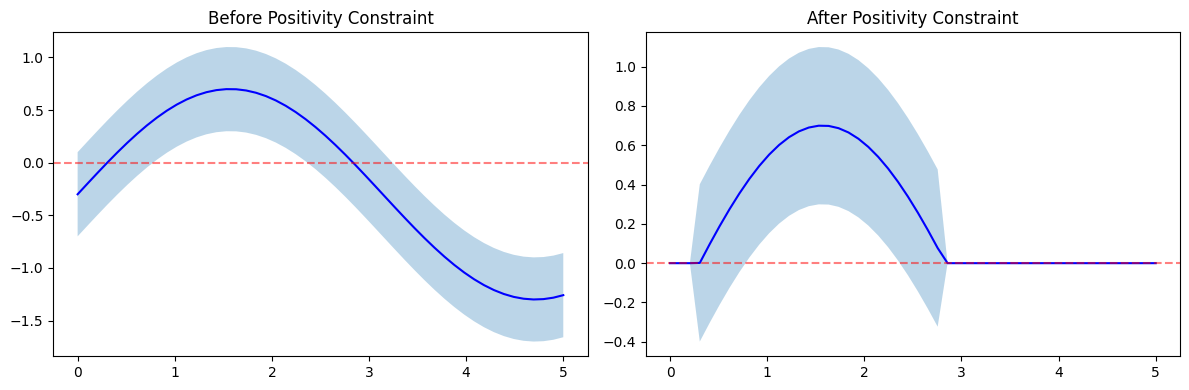

In [2]:
# Create a UQResult with some negative means (e.g., concentration predictions)
x = np.linspace(0, 5, 50)
mean = torch.tensor(np.sin(x) - 0.3, dtype=torch.float32)
var = torch.ones_like(mean) * 0.04  # std=0.2 -> var=0.04

result_before = UQResult(mean=mean, epistemic_var=var, total_var=var)
print(f"Before: {(result_before.mean < 0).sum().item()} negative values")
print(f"Min value: {result_before.mean.min().item():.3f}")

# Apply positivity constraint
constraint = PositivityConstraint()
result_after = constraint.apply(result_before)

print(f"\nAfter: {(result_after.mean < 0).sum().item()} negative values")
print(f"Min value: {result_after.mean.min().item():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, title in zip(axes, [result_before, result_after], ["Before", "After"]):
    m = res.mean.numpy()
    s = res.total_var.sqrt().numpy()
    ax.plot(x, m, "b-")
    ax.fill_between(x, m - 2*s, m + 2*s, alpha=0.3)
    ax.axhline(0, color="r", linestyle="--", alpha=0.5)
    ax.set_title(f"{title} Positivity Constraint")
plt.tight_layout()
plt.show()

## Conservation Constraint

### Applying Constraint

Conservation constraints enforce that the integral (or sum) of predictions equals a known constant, such as total mass or energy. This removes physically impossible predictions from the uncertainty set.

Integral before: 0.5526
Integral after: 1.0000


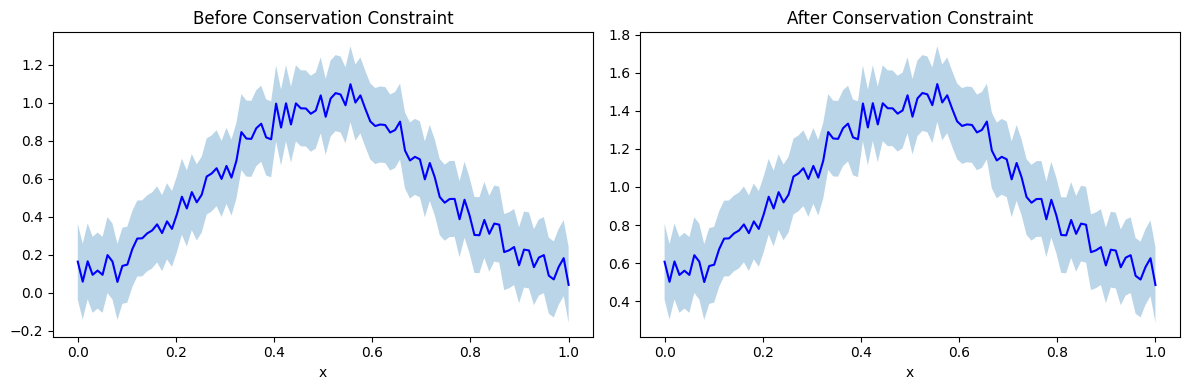

In [3]:
# Create UQResult representing a density field that should integrate to 1.0
x = np.linspace(0, 1, 100)
dx = x[1] - x[0]
mean = np.exp(-((x - 0.5)**2) / 0.1)  # Gaussian-like density
mean = mean + np.random.randn(100) * 0.05  # Add noise
mean_t = torch.tensor(mean, dtype=torch.float32)
var_t = torch.ones(100) * 0.01  # std=0.1

result_before = UQResult(mean=mean_t, epistemic_var=var_t, total_var=var_t)
weights = torch.ones(100) * dx  # Integration weights

print(f"Integral before: {(result_before.mean * weights).sum().item():.4f}")

# Apply conservation constraint
constraint = ConservationConstraint(integration_weights=weights, conserved_quantity=1.0)
result_after = constraint.apply(result_before)

print(f"Integral after: {(result_after.mean * weights).sum().item():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, title in zip(axes, [result_before, result_after], ["Before", "After"]):
    m = res.mean.numpy()
    s = res.total_var.sqrt().numpy()
    ax.plot(x, m, "b-")
    ax.fill_between(x, m - 2*s, m + 2*s, alpha=0.3)
    ax.set_title(f"{title} Conservation Constraint")
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

## Monotonicity Constraint

### Applying Constraint

Monotonicity constraints ensure predictions are non-decreasing (or non-increasing), appropriate for cumulative quantities, survival functions, or any process with a known directional trend.

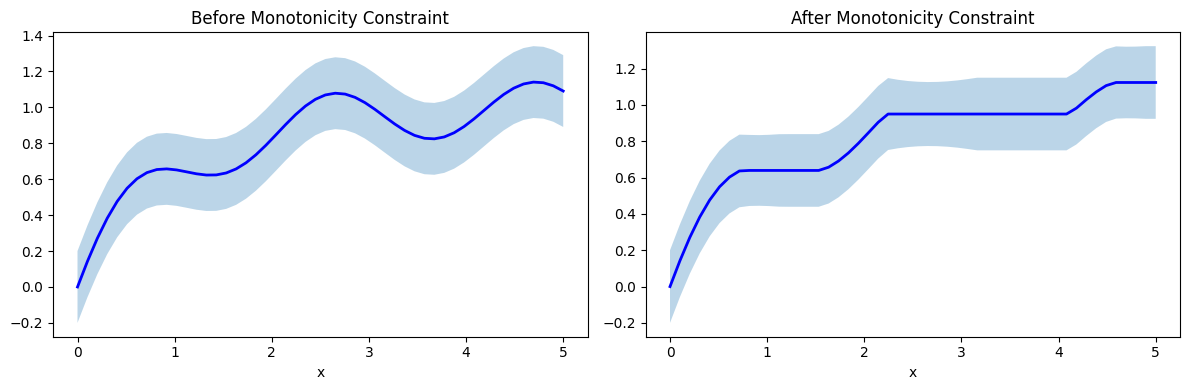

In [4]:
# Create UQResult with non-monotone mean (e.g., CDF that should be monotone)
x = np.linspace(0, 5, 50)
mean = torch.tensor(1 - np.exp(-x) + 0.15 * np.sin(3 * x), dtype=torch.float32)
var = torch.ones(50) * 0.01

result_before = UQResult(mean=mean, epistemic_var=var, total_var=var)

# Apply monotonicity constraint
constraint = MonotonicityConstraint()
result_after = constraint.apply(result_before)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, title in zip(axes, [result_before, result_after], ["Before", "After"]):
    m = res.mean.numpy()
    s = res.total_var.sqrt().numpy()
    ax.plot(x, m, "b-", linewidth=2)
    ax.fill_between(x, m - 2*s, m + 2*s, alpha=0.3)
    ax.set_title(f"{title} Monotonicity Constraint")
    ax.set_xlabel("x")
plt.tight_layout()
plt.show()

## Combining Constraints

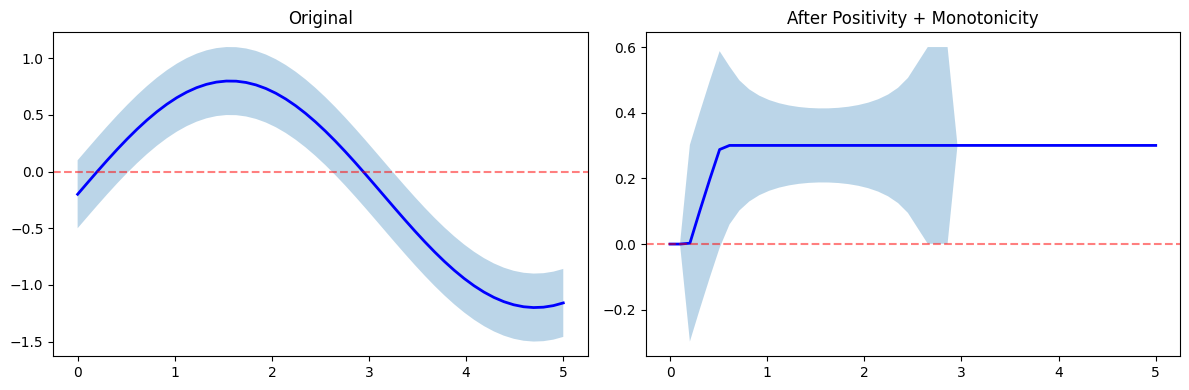

In [5]:
# Apply multiple constraints sequentially
x = np.linspace(0, 5, 50)
mean = torch.tensor(np.sin(x) - 0.2, dtype=torch.float32)
var = torch.ones(50) * 0.0225  # std=0.15

result = UQResult(mean=mean, epistemic_var=var, total_var=var)

constraints = [PositivityConstraint(), MonotonicityConstraint()]
result_final = apply_constraints(result, constraints)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
m_orig = mean.numpy()
s_orig = np.sqrt(0.0225)
axes[0].plot(x, m_orig, "b-", linewidth=2)
axes[0].fill_between(x, m_orig - 2*s_orig, m_orig + 2*s_orig, alpha=0.3)
axes[0].axhline(0, color="r", linestyle="--", alpha=0.5)
axes[0].set_title("Original")

m_final = result_final.mean.numpy()
s_final = result_final.total_var.sqrt().numpy()
axes[1].plot(x, m_final, "b-", linewidth=2)
axes[1].fill_between(x, m_final - 2*s_final, m_final + 2*s_final, alpha=0.3)
axes[1].axhline(0, color="r", linestyle="--", alpha=0.5)
axes[1].set_title("After Positivity + Monotonicity")

plt.tight_layout()
plt.show()